In [24]:
import sys; import os; sys.path.append(os.path.abspath('..'))

import importlib; from module import similarity as sm; importlib.reload(sm)

<module 'module.similarity' from 'c:\\PARK\\School\\텍스트데이터분석을 위한 딥러닝\\개별 프로젝트\\Song Lyrics Sentiment Analysis\\module\\similarity\\__init__.py'>

In [1]:
import pandas as pd

# 데이터 불러오기
df = pd.read_pickle("../results/emotion_analysis.pkl")

# 감정군 목록
emotion_list = ["love", "sadness", "anger", "hope", "surprise"]

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75879 entries, 0 to 75878
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   title                     75879 non-null  object 
 1   artist                    75879 non-null  object 
 2   genre                     75879 non-null  object 
 3   views                     75879 non-null  int64  
 4   year                      75879 non-null  int64  
 5   total_tokens              75879 non-null  int64  
 6   emotion_word_count        75879 non-null  int64  
 7   emotion_word_ratio        75879 non-null  float64
 8   emotion_words             75879 non-null  object 
 9   count_anger               75879 non-null  int64  
 10  ratio_anger               75879 non-null  float64
 11  count_hope                75879 non-null  int64  
 12  ratio_hope                75879 non-null  float64
 13  count_love                75879 non-null  int64  
 14  ratio_

# 샘플로 테스트

In [77]:
sample_df = df.sample(5000, random_state=42)
sample_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 60141 to 40973
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   title                     5000 non-null   object 
 1   artist                    5000 non-null   object 
 2   genre                     5000 non-null   object 
 3   views                     5000 non-null   int64  
 4   year                      5000 non-null   int64  
 5   total_tokens              5000 non-null   int64  
 6   emotion_word_count        5000 non-null   int64  
 7   emotion_word_ratio        5000 non-null   float64
 8   emotion_words             5000 non-null   object 
 9   count_anger               5000 non-null   int64  
 10  ratio_anger               5000 non-null   float64
 11  count_hope                5000 non-null   int64  
 12  ratio_hope                5000 non-null   float64
 13  count_love                5000 non-null   int64  
 14  ratio_lo

## 유사도 분석

In [78]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [79]:
documents = sample_df["emotion_words"].apply(lambda x: ' '.join(x.split(', '))).tolist()

In [80]:
# TF-IDF 벡터화
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(documents)

In [81]:
tfidf_matrix.shape

(5000, 4693)

In [82]:
# 코사인 유사도 계산
similarity_matrix = cosine_similarity(tfidf_matrix)

In [83]:
similarity_matrix.shape

(5000, 5000)

In [84]:
# 특정 노래 100번과 유사한 top-5 곡 찾기
import numpy as np

target_index = 997
top_indices = np.argsort(similarity_matrix[target_index])[::-1][1:6]  # 자기 자신 제외

sample_df.iloc[[target_index] + top_indices.tolist()][['title', 'artist', 'genre', 'year']]

,title,artist,genre,year
8161,Cold,Post Malone,rap,2016
24750,​until its over closure,Juice WRLD,rap,2017
12520,Bad Reputation,Shawn Mendes,pop,2016
61334,Wutup Snow?,Jon Bellion,rap,2013
60331,1999,beabadoobee,pop,2019
45616,Excuse My Pain,J.I the Prince of N.Y,rap,2020


## 클러스터링

In [134]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

def find_best_k(tfidf_matrix, k_range=range(2, 11)):
    inertias = []
    silhouettes = []

    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42)
        labels = kmeans.fit_predict(tfidf_matrix)
        inertias.append(kmeans.inertia_)
        silhouettes.append(silhouette_score(tfidf_matrix, labels))

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(k_range, inertias, marker='o')
    plt.title("Elbow Method (Inertia)")
    plt.xlabel("k")
    plt.ylabel("Inertia")

    plt.subplot(1, 2, 2)
    plt.plot(k_range, silhouettes, marker='o')
    plt.title("Silhouette Score")
    plt.xlabel("k")
    plt.ylabel("Score")

    plt.tight_layout()
    plt.show()

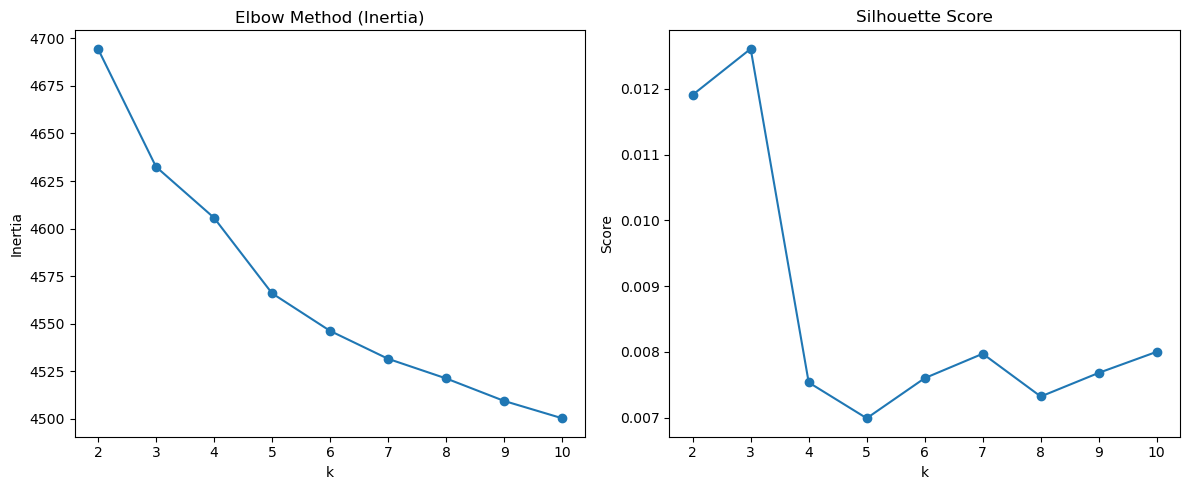

In [135]:
find_best_k(tfidf_matrix, k_range=range(2, 11))

In [144]:
# KMeans 클러스터링
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(tfidf_matrix)
np.unique(kmeans_labels)

array([0, 1, 2])

In [87]:
# Mean Shift 클러스터링
from sklearn.cluster import MeanShift, estimate_bandwidth

best_bandwidth = estimate_bandwidth(tfidf_matrix.toarray())
print('bandwidth 값:', round(best_bandwidth,3))

mean_shift = MeanShift(bandwidth=best_bandwidth, bin_seeding=True)
mean_shift_labels = mean_shift.fit_predict(tfidf_matrix.toarray())
np.unique(mean_shift_labels)

bandwidth 값: 1.378


array([0], dtype=int64)

In [106]:
# DBSCAN (Density-Based Spatial Clustering of Applications with Noise)
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=7, metric='cosine')
dbscan_labels = dbscan.fit_predict(tfidf_matrix)
np.unique(dbscan_labels)

array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11], dtype=int64)

In [ ]:
# Gaussian Mixture Models (GMM)
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=5, random_state=42)
gmm_labels = gmm.fit_predict(tfidf_matrix.toarray())
np.unique(gmm_labels)

In [114]:
# Agglomerative Hierarchical 클러스터링
from sklearn.cluster import AgglomerativeClustering

# TF-IDF 벡터로부터 0 벡터(모든 요소가 0인 행) 제거
dense_matrix = tfidf_matrix.toarray()
nonzero_mask = np.any(dense_matrix != 0, axis=1)

# 필터링된 벡터와 데이터프레임
filtered_matrix = dense_matrix[nonzero_mask]
filtered_df = sample_df[nonzero_mask].reset_index(drop=True)

hierarchical = AgglomerativeClustering(n_clusters=5, metric='cosine', linkage='average')
hierarchical_labels = hierarchical.fit_predict(filtered_matrix)
np.unique(hierarchical_labels)

array([0, 1, 2, 3, 4], dtype=int64)

## 클러스터 해석 및 시각화

In [138]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

pca = PCA(n_components=2, random_state=42)
reduced = pca.fit_transform(tfidf_matrix.toarray())

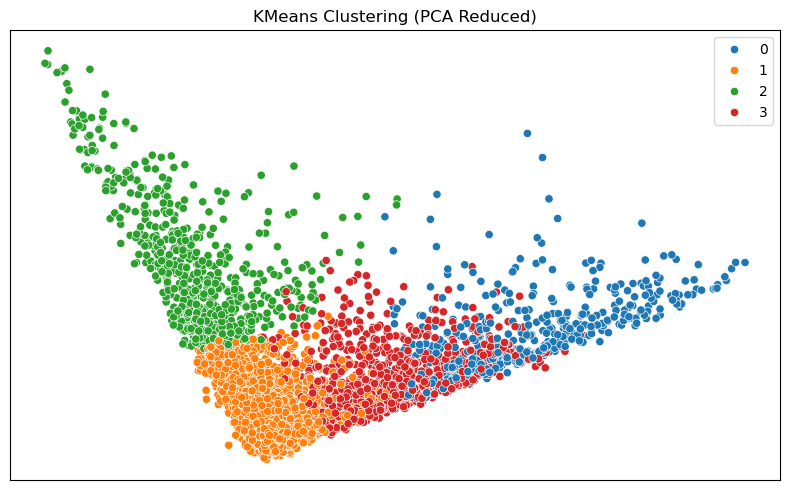

In [142]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(x=reduced[:, 0], y=reduced[:, 1], hue=kmeans_labels, palette='tab10', legend='full')
ax.set_title('KMeans Clustering (PCA Reduced)')
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.show()

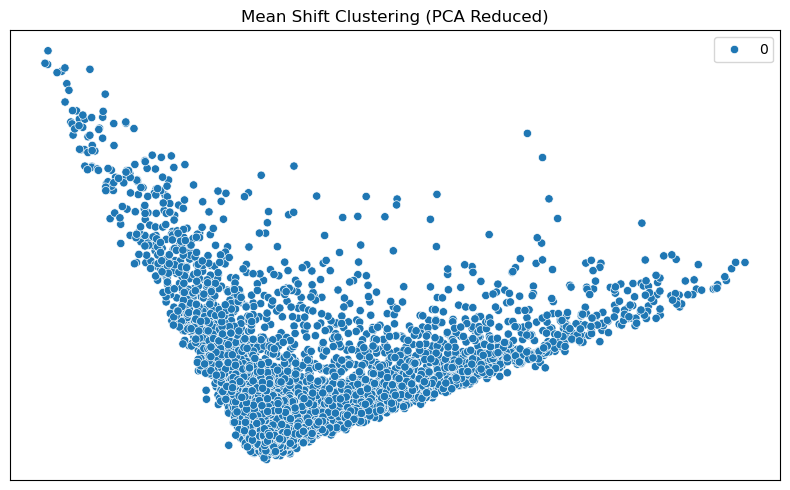

In [91]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(x=reduced[:, 0], y=reduced[:, 1], hue=mean_shift_labels, palette='tab10', legend='full')
ax.set_title('Mean Shift Clustering (PCA Reduced)')
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.show()

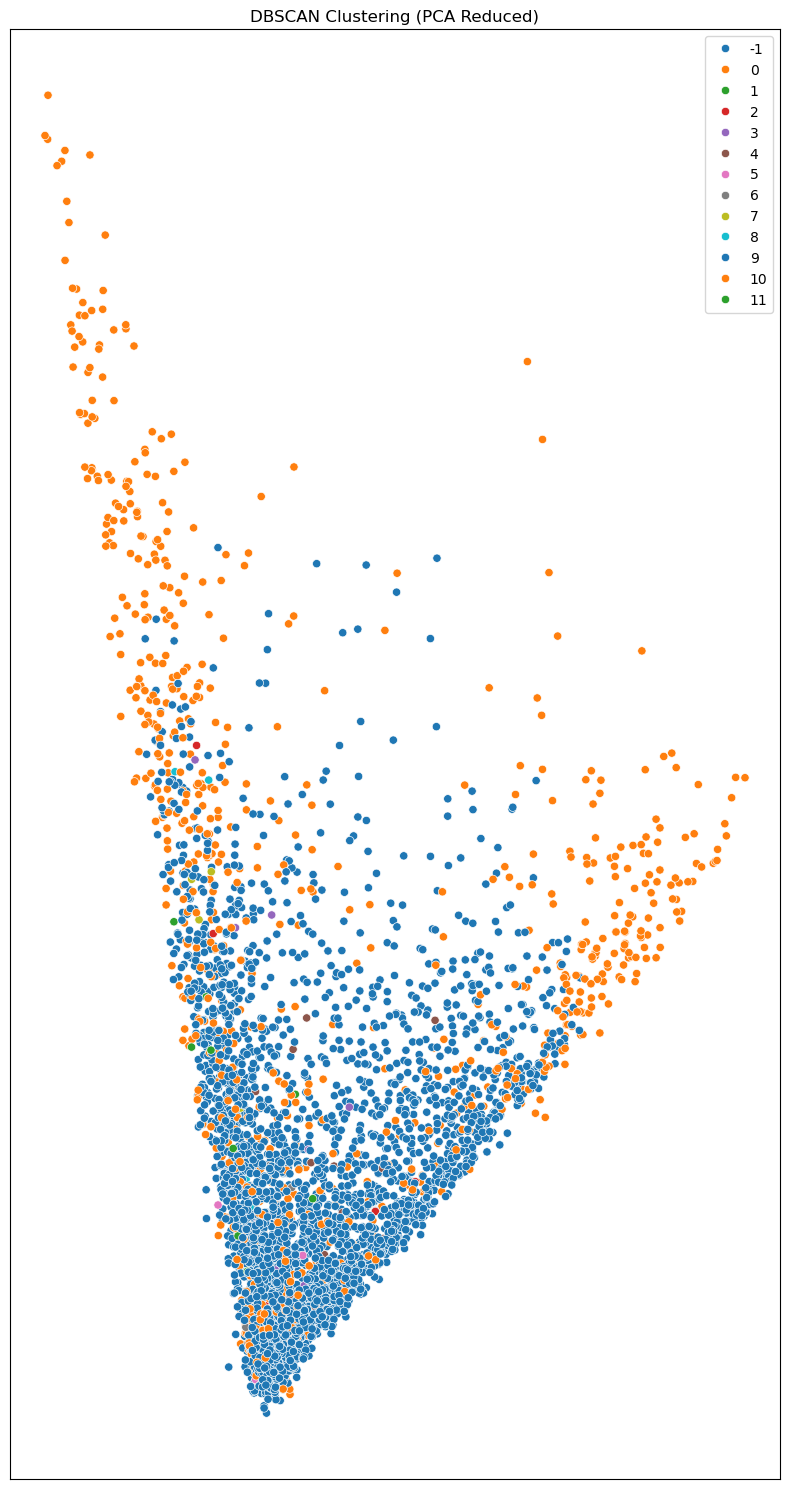

In [107]:
fig, ax = plt.subplots(figsize=(8, 15))
sns.scatterplot(x=reduced[:, 0], y=reduced[:, 1], hue=dbscan_labels, palette='tab10', legend='full')
ax.set_title('DBSCAN Clustering (PCA Reduced)')
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.show()

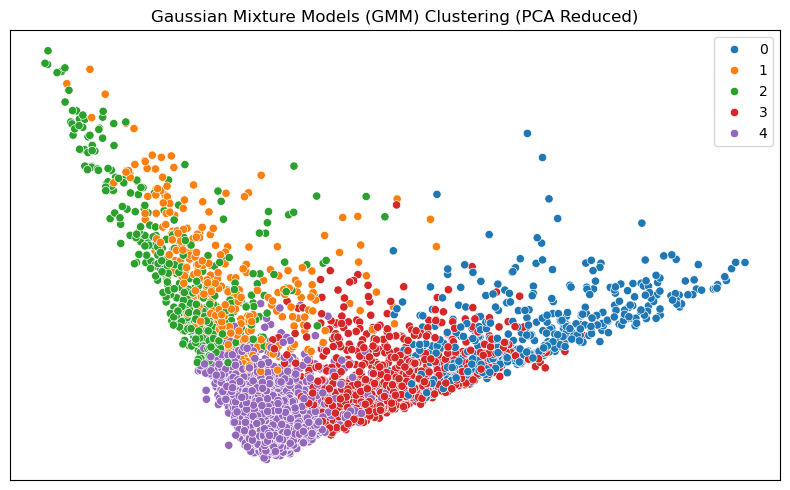

In [112]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(x=reduced[:, 0], y=reduced[:, 1], hue=gmm_labels, palette='tab10', legend='full')
ax.set_title('Gaussian Mixture Models (GMM) Clustering (PCA Reduced)')
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.show()

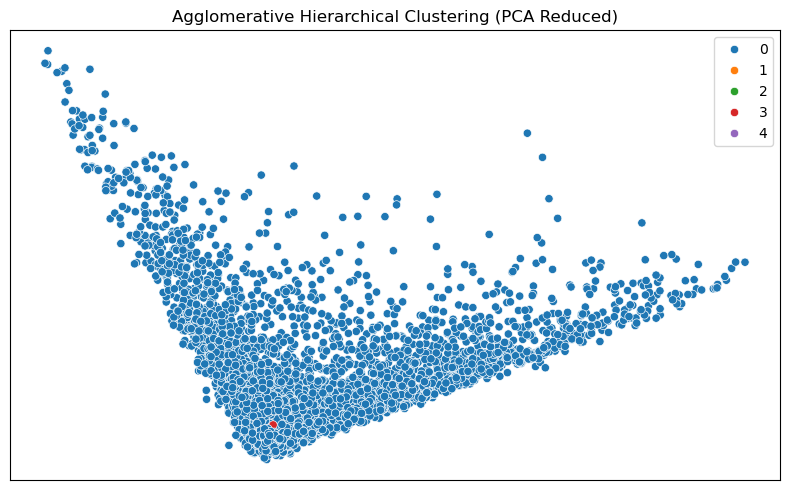

In [120]:
reduced = pca.fit_transform(filtered_matrix)

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(x=reduced[:, 0], y=reduced[:, 1], hue=hierarchical_labels, palette='tab10', legend='full')
ax.set_title('Agglomerative Hierarchical Clustering (PCA Reduced)')
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.show()

In [132]:
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_and_visualize_clusters(plot_df, cluster, labels, emotion_columns):
    plot_df = plot_df.copy()
    # 클러스터 컬럼 추가
    plot_df[f'{cluster}_cluster'] = labels

    # 클러스터 개수
    n_clusters = len(set(labels))

    for cluster_id in range(n_clusters):
        cluster_df = plot_df[plot_df[f'{cluster}_cluster'] == cluster_id]

        cluster_df['emotion_words'] = cluster_df['emotion_words'].apply(lambda x: x.split(', '))

        # 1. 감정군 평균 값 barplot
        mean_scores = cluster_df[[f"count_{emo}" for emo in emotion_columns]].mean().sort_values(ascending=False)

        plt.figure(figsize=(8, 5))
        sns.barplot(x=mean_scores.index, y=mean_scores.values)
        plt.title(f'{cluster.capitalize()} Cluster {cluster_id} - Average Emotion Scores')
        plt.ylabel('Mean Score')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        plt.close()

        # 2. 클러스터 내 전체 감정 단어 워드클라우드
        all_words = [word for sublist in cluster_df['emotion_words'] for word in sublist]
        word_freq = dict(Counter(all_words))
        wordcloud = WordCloud(width=800, height=400, collocations=False, background_color='white').generate_from_frequencies(word_freq)

        plt.figure(figsize=(10, 5))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title(f'{cluster.capitalize()} Cluster {cluster_id} - Emotion WordCloud')
        plt.tight_layout()
        plt.show()
        plt.close()

C:\Users\박상춘\AppData\Local\Temp\ipykernel_21904\843509542.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_df['emotion_words'] = cluster_df['emotion_words'].apply(lambda x: x.split(', '))


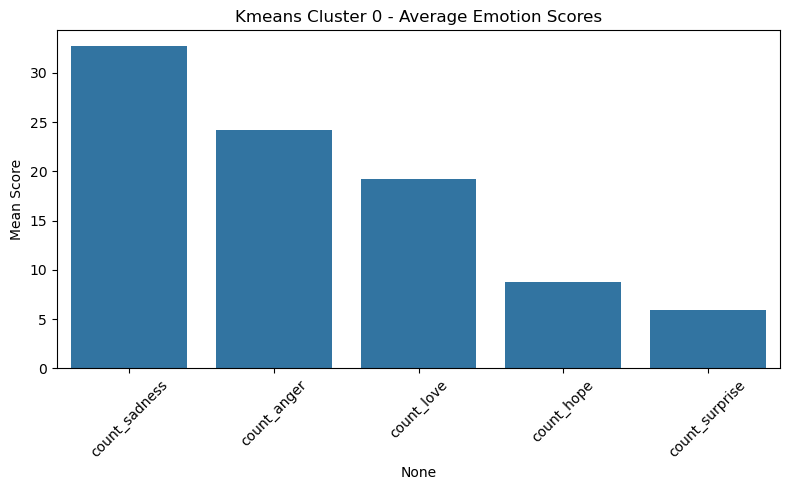

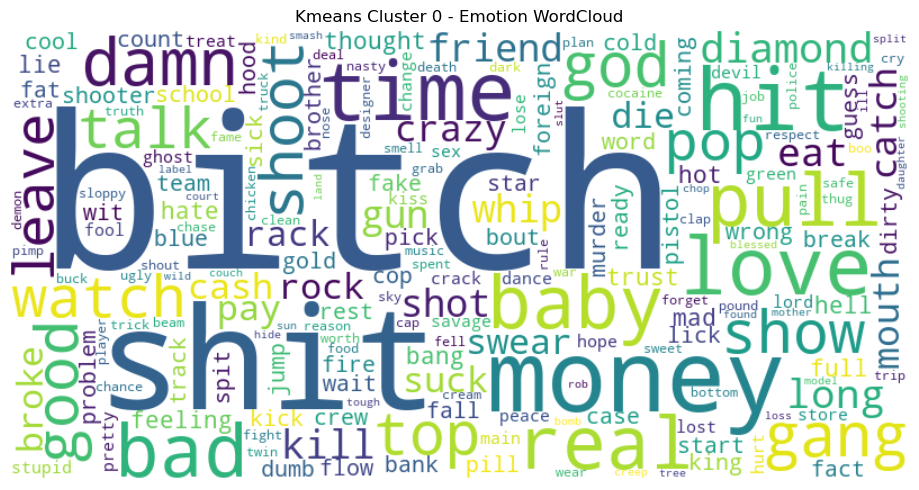

C:\Users\박상춘\AppData\Local\Temp\ipykernel_21904\843509542.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_df['emotion_words'] = cluster_df['emotion_words'].apply(lambda x: x.split(', '))


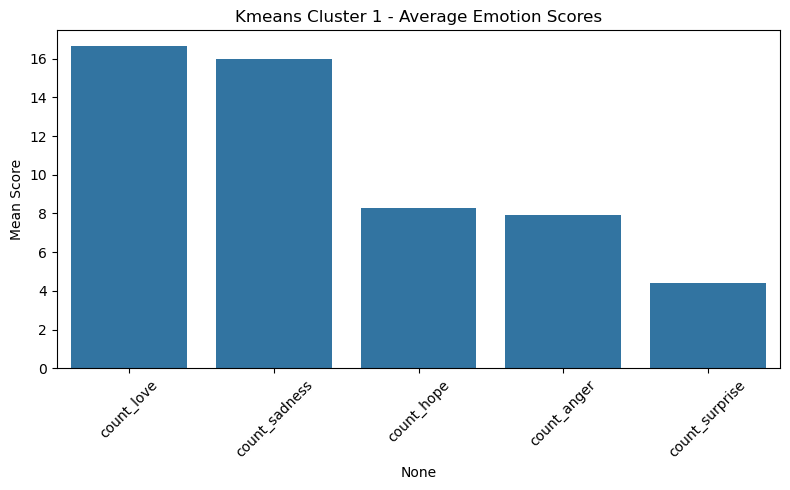

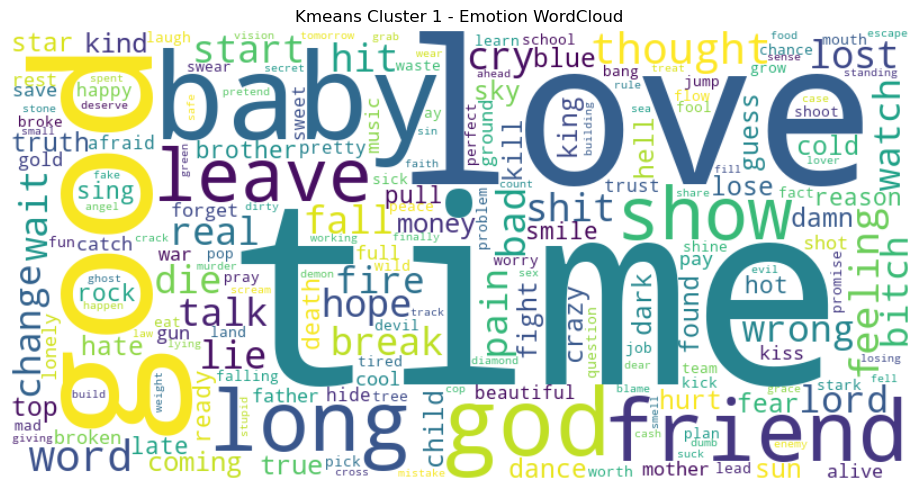

C:\Users\박상춘\AppData\Local\Temp\ipykernel_21904\843509542.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_df['emotion_words'] = cluster_df['emotion_words'].apply(lambda x: x.split(', '))


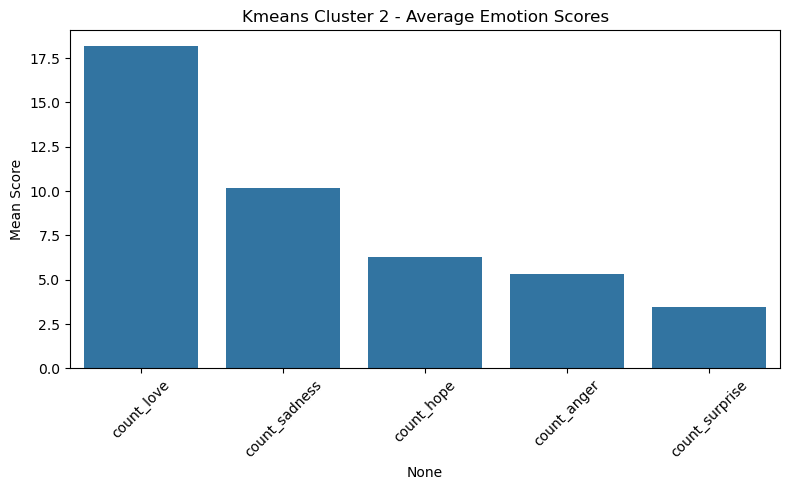

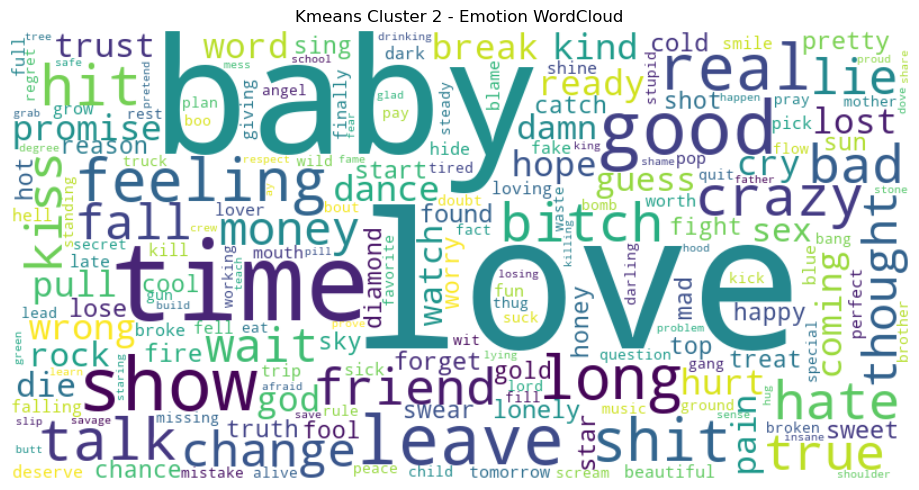

C:\Users\박상춘\AppData\Local\Temp\ipykernel_21904\843509542.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_df['emotion_words'] = cluster_df['emotion_words'].apply(lambda x: x.split(', '))


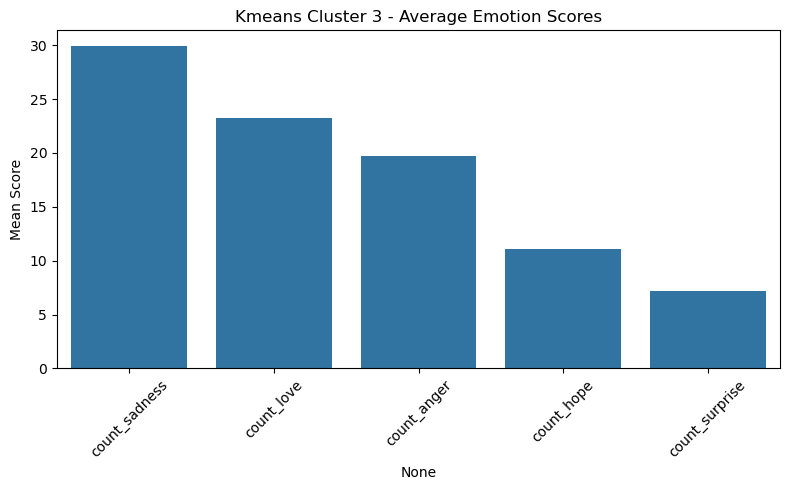

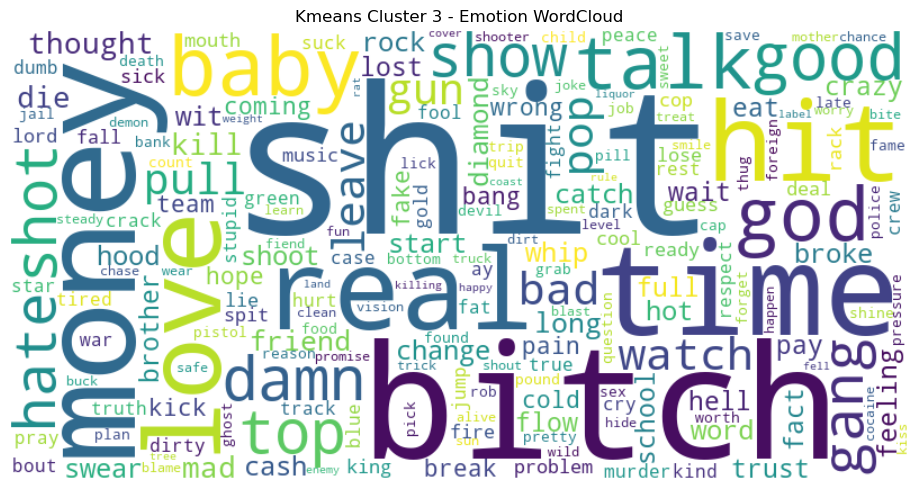

In [143]:
analyze_and_visualize_clusters(sample_df, 'kmeans', kmeans_labels, emotion_list)
# analyze_and_visualize_clusters(sample_df, 'mean_shift', mean_shift_labels, emotion_list)
# # analyze_and_visualize_clusters(sample_df, 'dbscan', dbscan_labels, emotion_list)
# analyze_and_visualize_clusters(sample_df, 'gmm', gmm_labels, emotion_list)
# analyze_and_visualize_clusters(filtered_df, 'hierarchical', hierarchical_labels, emotion_list)

## 클러스터별 장르/시대 연관 분석

## 개인 추천 알고리즘 설계

In [ ]:
# 사용자가 좋아한 곡들 (예: 상위 joy 점수 곡들 일부 선택)
user_songs = sample_df[sample_df['joy'] > 0.5].sample(n=5)

# 사용자 감정 프로필 생성
user_profile = sm.get_user_emotion_profile(user_songs, emotion_list)

# 추천 결과
recommend_df = sm.recommend_songs_by_profile(df, user_profile, emotion_list, cluster_col='cluster', top_n=10)